In [1]:
from utility import load_test_results, architecture_stats, sample_image

from NeuralNetwork import NeuralNetwork, torch

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.min_rows', 5000)
pd.set_option('display.max_rows', 5000)

In [2]:
classifiers_dict, all_results = load_test_results("Classifier_1")

In [3]:
classifiers_dict

{0: "Classifier_1 (n_neurons_molt_factor=1, do_dropout=['FC1'])",
 1: 'Classifier_1 (n_neurons_molt_factor=2, do_dropout=[])',
 2: 'Classifier_1 (n_neurons_molt_factor=1, do_dropout=[])',
 3: "Classifier_1 (n_neurons_molt_factor=0.6, do_dropout=['FC1'])",
 4: "Classifier_1 (n_neurons_molt_factor=2, do_dropout=['FC1'])",
 5: 'Classifier_1 (n_neurons_molt_factor=0.6, do_dropout=[])'}

In [4]:
all_results.head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
0,0,0,1.0,['FC1'],0.0005,32,5,0.00,0.020078,0.040674,36.926770
1,1,0,1.0,['FC1'],0.0005,32,5,0.25,0.020078,0.040804,45.390522
2,2,0,1.0,['FC1'],0.0005,32,5,0.50,0.020078,0.040663,4.859825
3,3,0,1.0,['FC1'],0.0005,32,5,0.75,0.020078,0.040737,3.748900
4,4,0,1.0,['FC1'],0.0005,32,10,0.00,0.020078,0.040754,4.060791
5,5,0,1.0,['FC1'],0.0005,32,10,0.25,0.020078,0.040630,4.970676
6,6,0,1.0,['FC1'],0.0005,32,10,0.50,0.020078,0.040596,9.694519
7,7,0,1.0,['FC1'],0.0005,32,10,0.75,0.020078,0.040640,6.856224
8,8,0,1.0,['FC1'],0.0005,32,15,0.00,0.020078,0.040516,5.869636
9,9,0,1.0,['FC1'],0.0005,32,15,0.25,0.020078,0.040702,7.277014


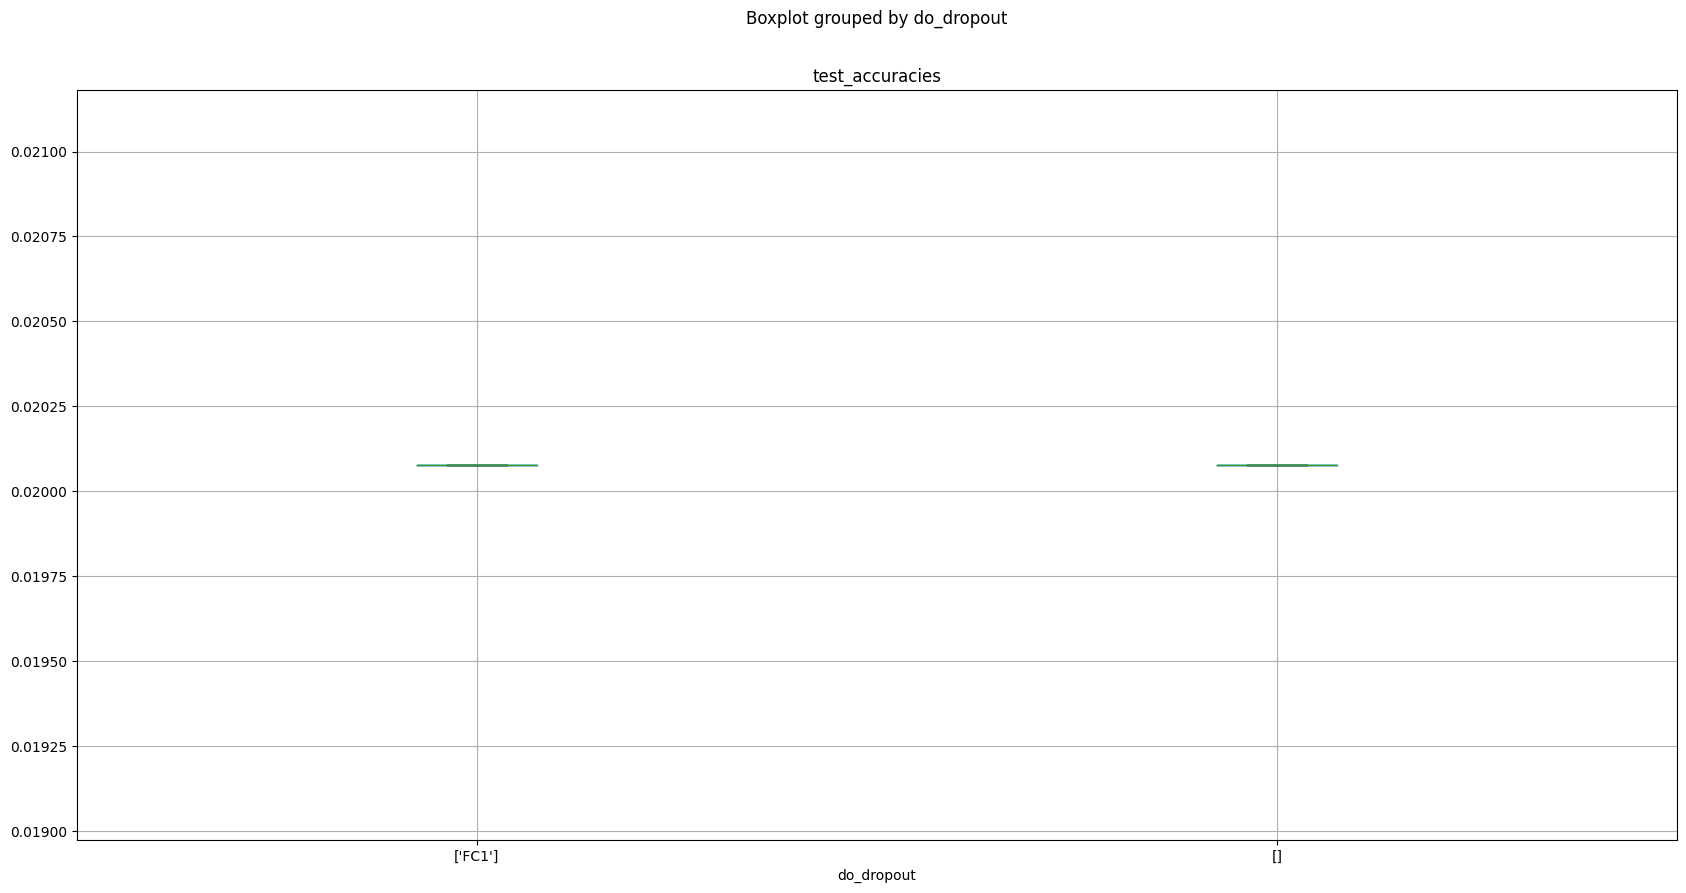

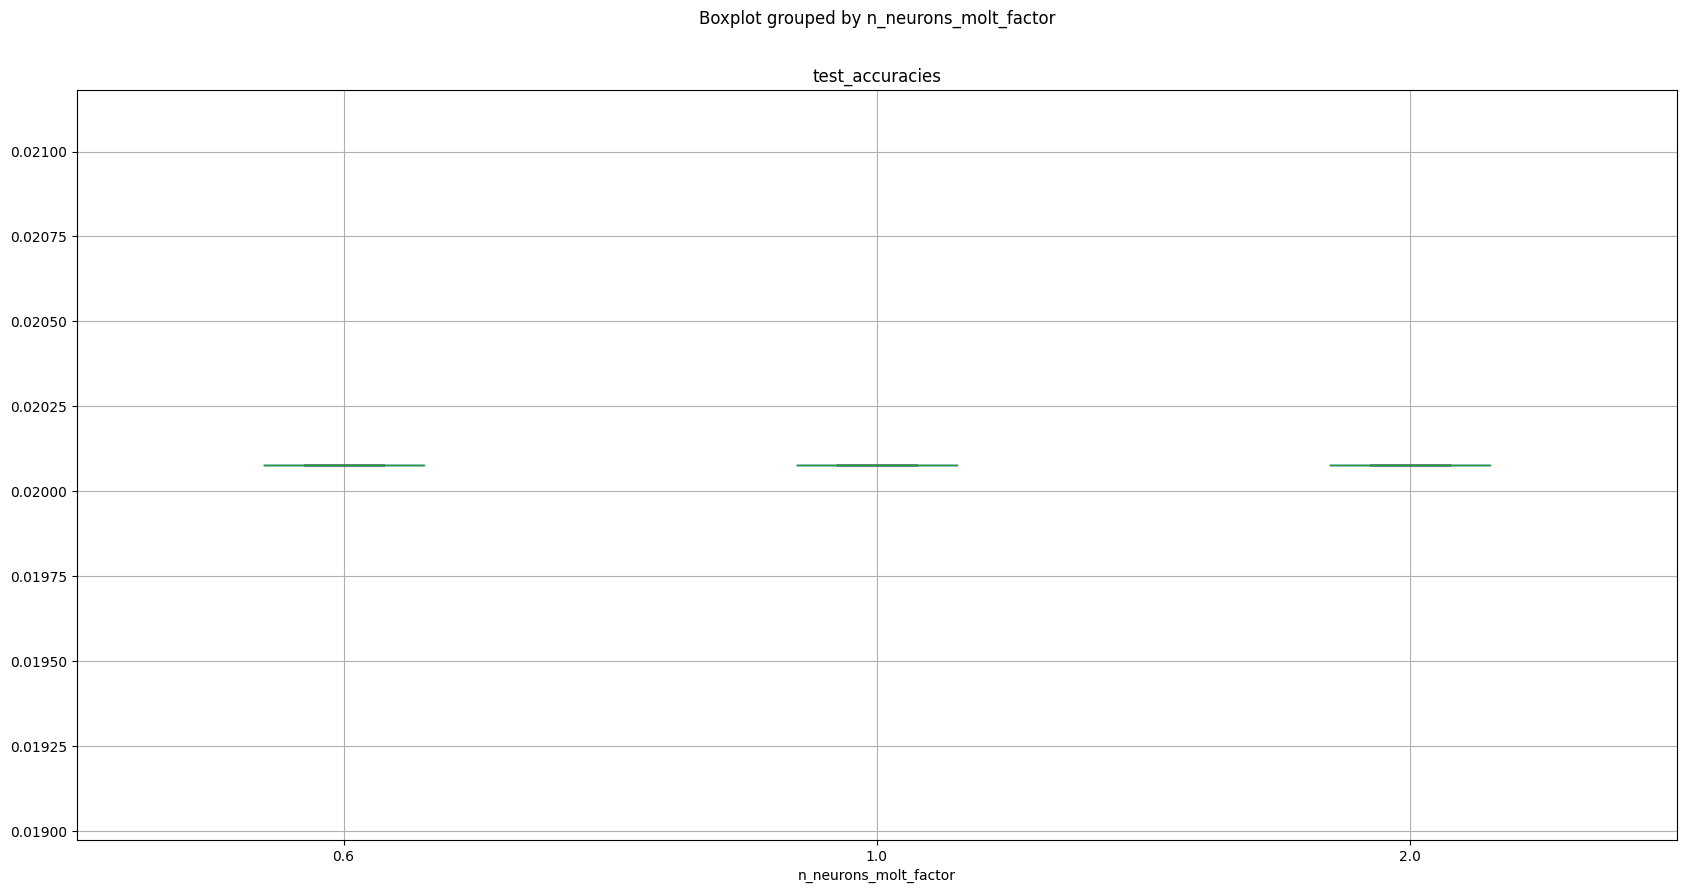

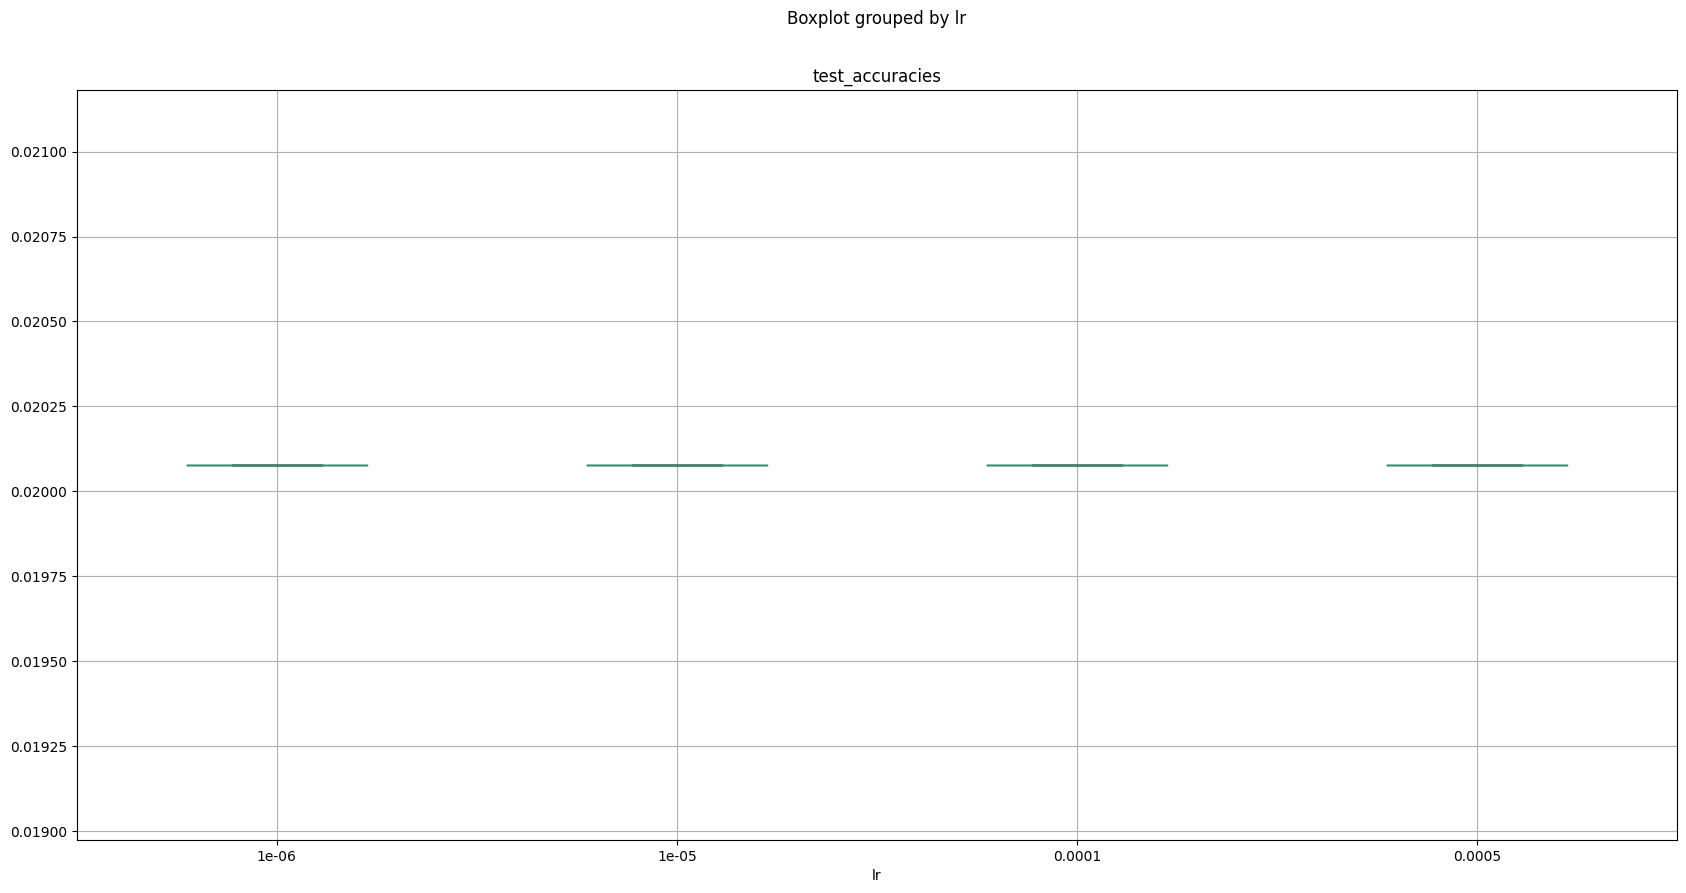

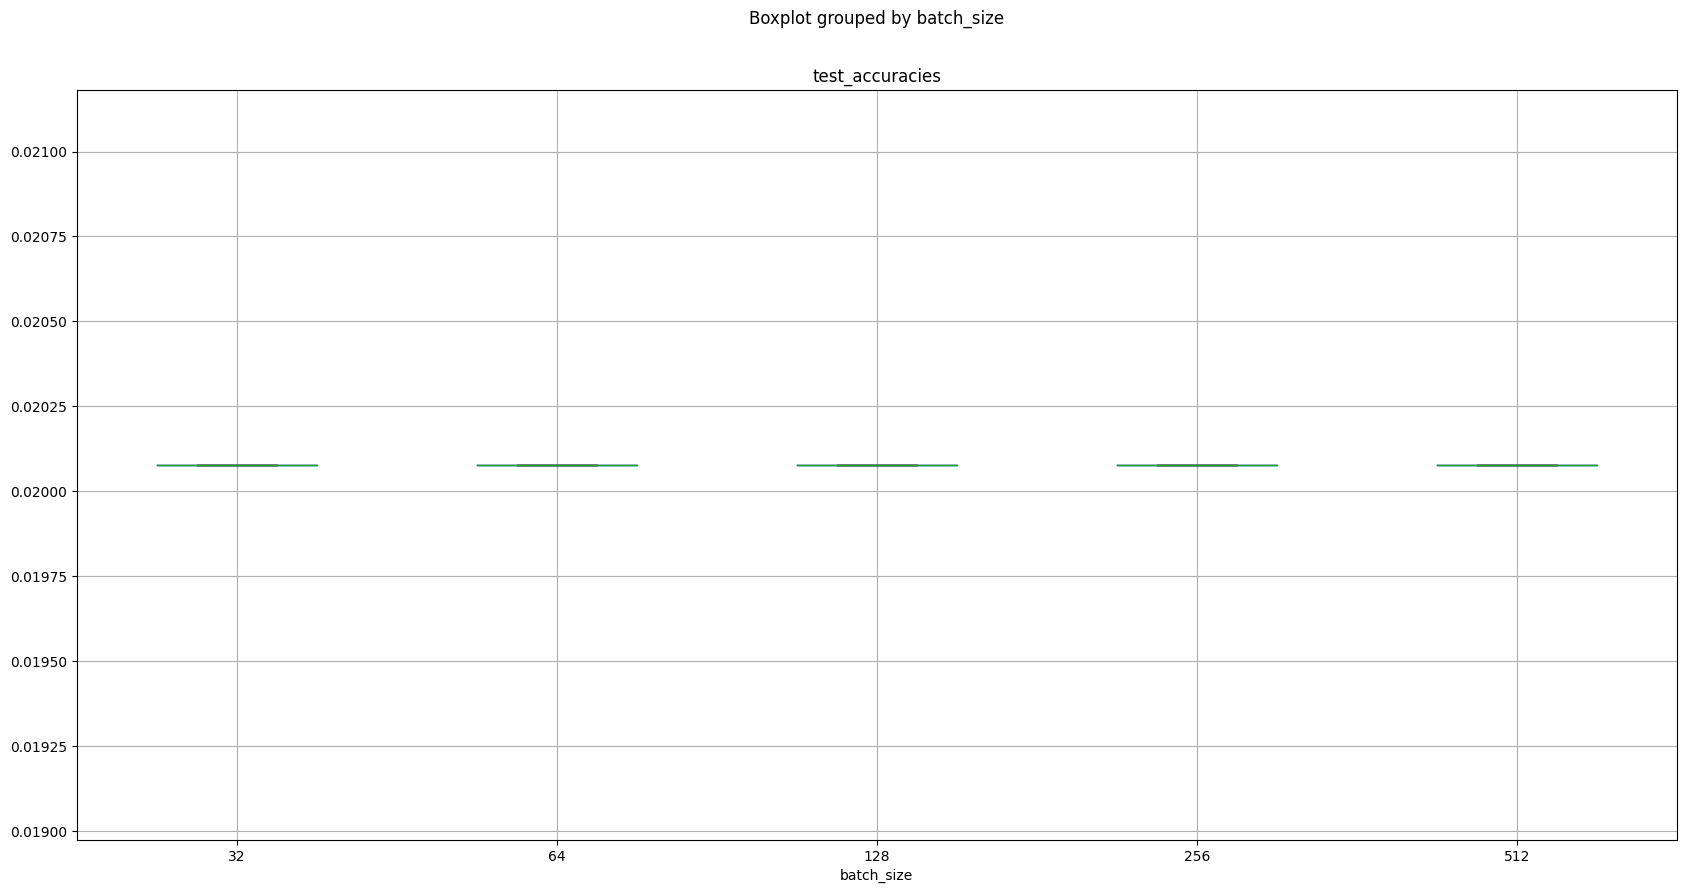

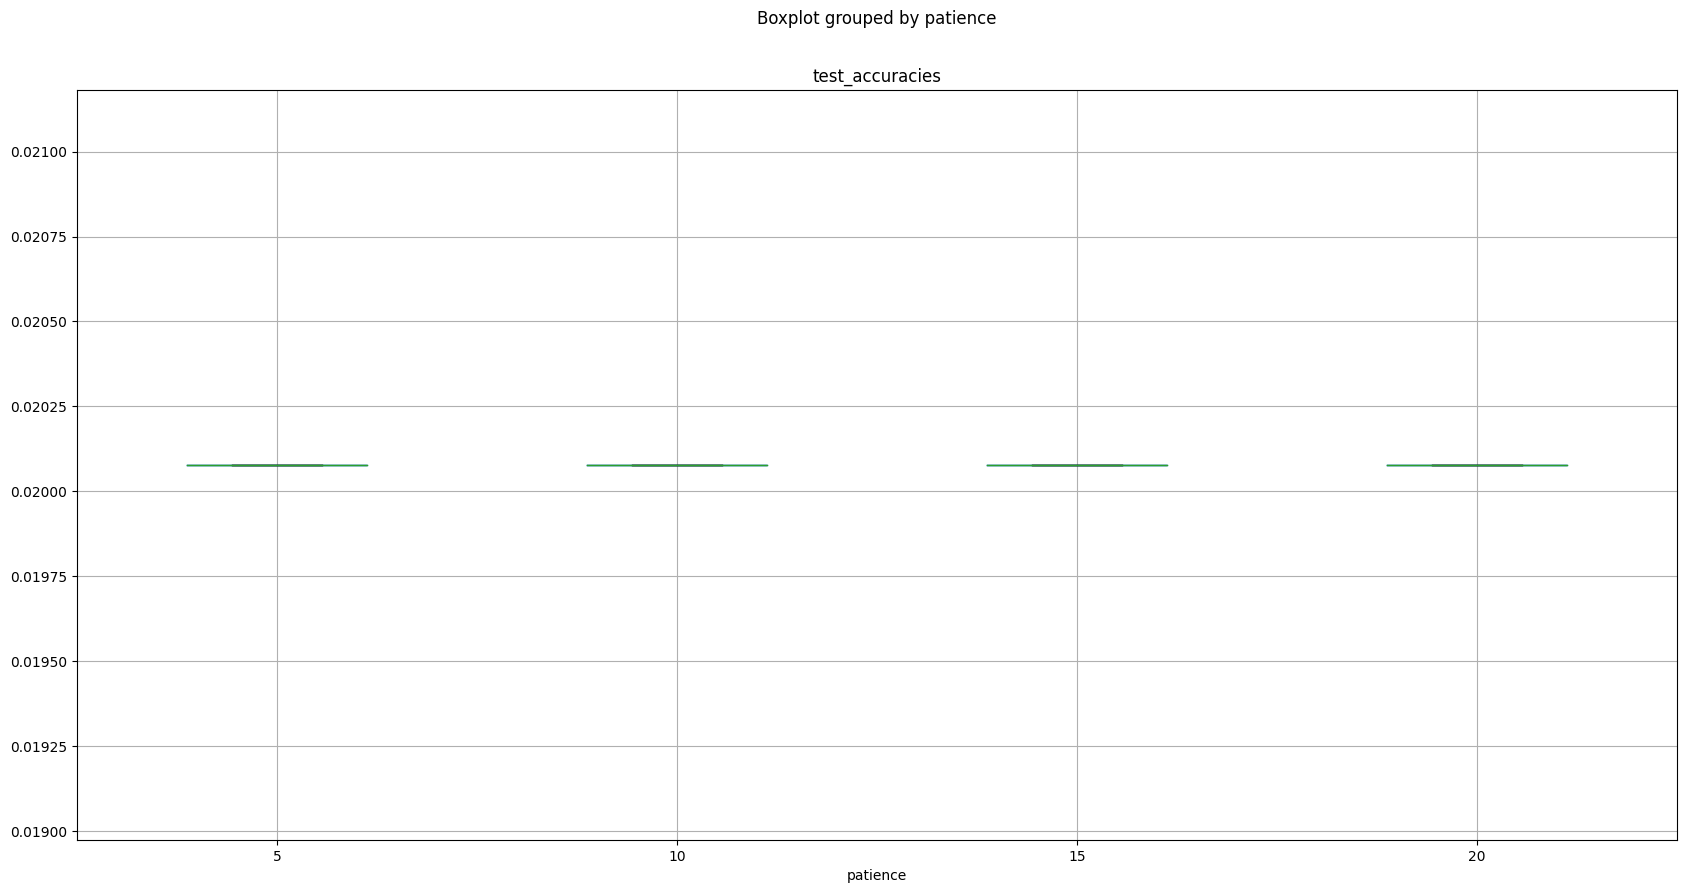

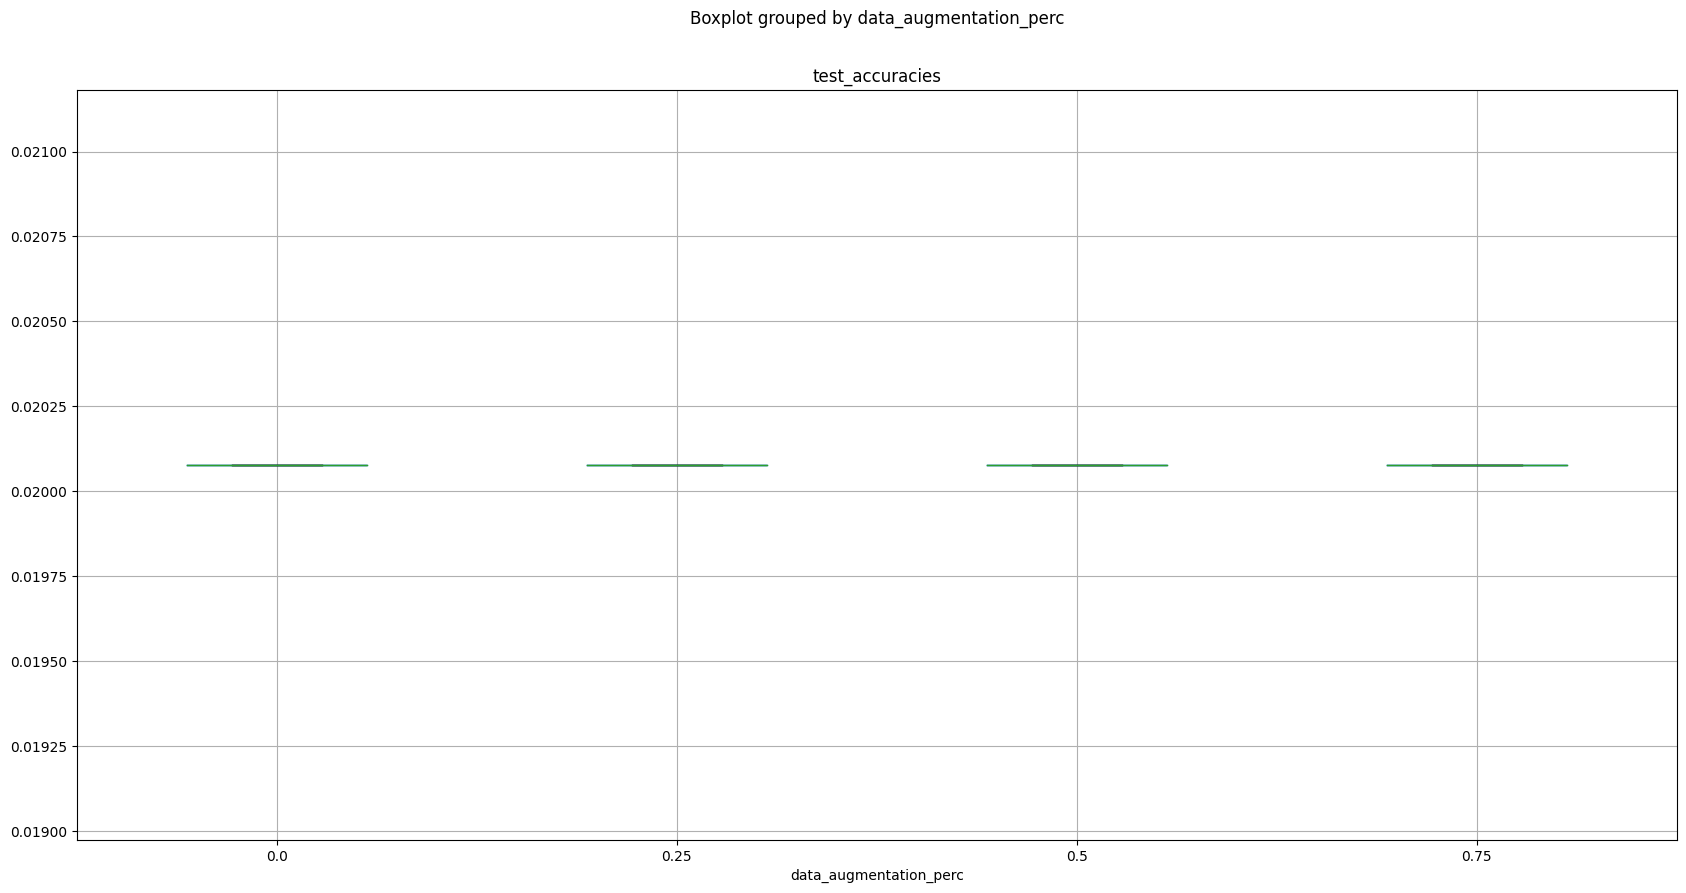

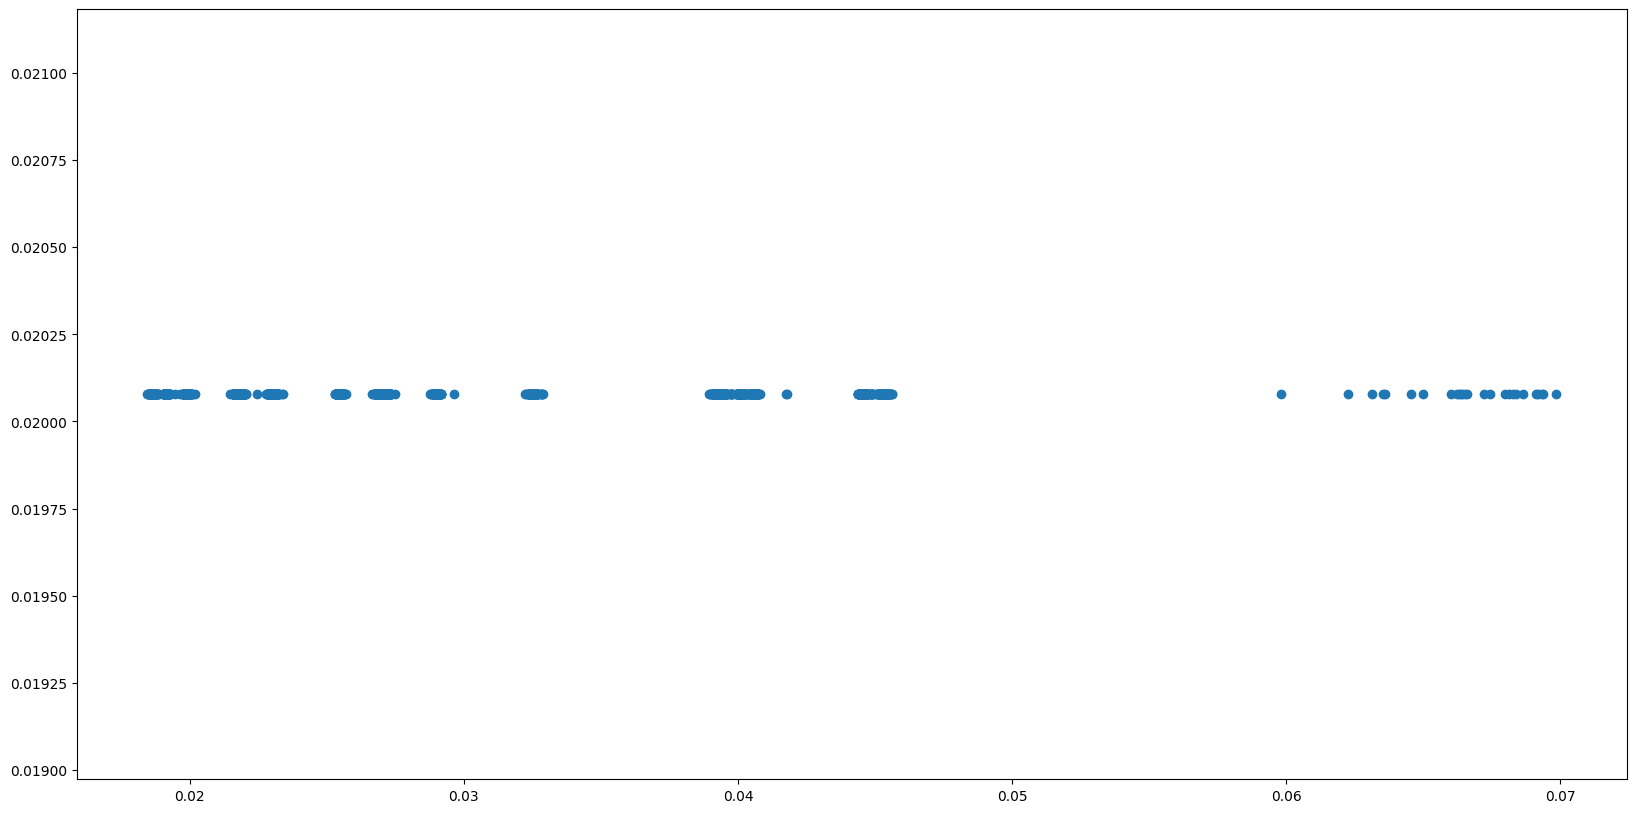

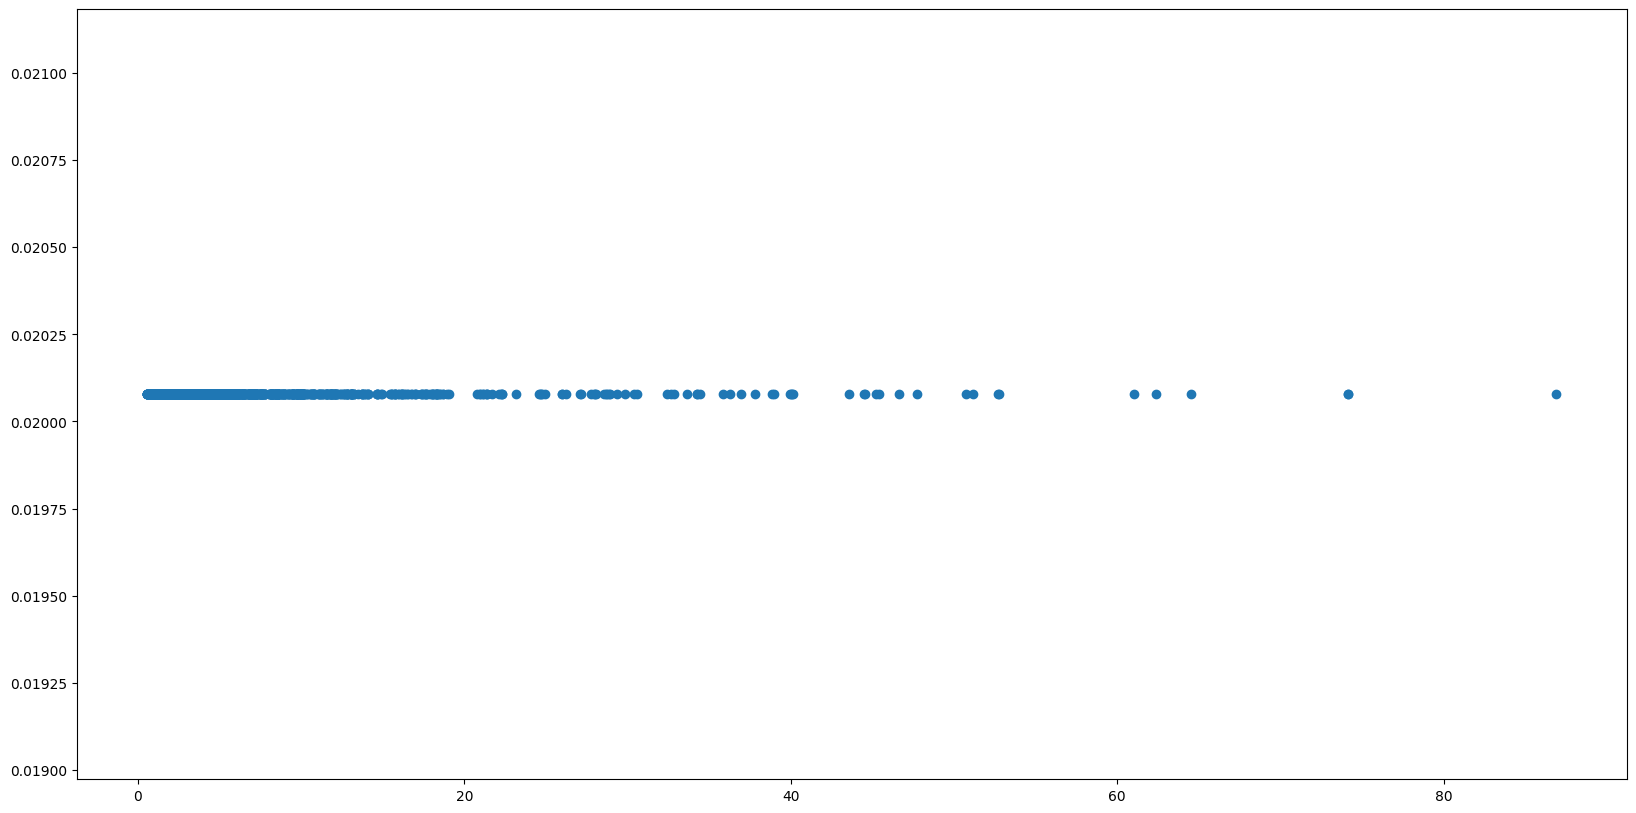

In [5]:
def plot_hyper():
    
    fig,ax=plt.subplots(figsize=(20,10))
    prova = all_results.sort_values(by="do_dropout")
    prova.boxplot(column =["test_accuracies"], by="do_dropout", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="n_neurons_molt_factor", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="lr", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="batch_size", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="patience", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="data_augmentation_perc", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    ax.scatter(all_results["test_times"], all_results["test_accuracies"])
    
    fig,ax=plt.subplots(figsize=(20,10))
    ax.scatter(all_results["train_times"], all_results["test_accuracies"])

plot_hyper()

In [6]:
all_results.sort_values(by=['test_accuracies'], ascending=False).head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
0,0,0,1.0,['FC1'],0.0005,32,5,0.00,0.020078,0.040674,36.926770
1,1,0,1.0,['FC1'],0.0005,32,5,0.25,0.020078,0.040804,45.390522
1288,8,4,2.0,['FC1'],0.0005,32,15,0.00,0.020078,0.044723,8.186942
1287,7,4,2.0,['FC1'],0.0005,32,10,0.75,0.020078,0.044584,17.421608
1286,6,4,2.0,['FC1'],0.0005,32,10,0.50,0.020078,0.044640,8.255956
1285,5,4,2.0,['FC1'],0.0005,32,10,0.25,0.020078,0.044749,6.985015
1284,4,4,2.0,['FC1'],0.0005,32,10,0.00,0.020078,0.044886,5.660945
1283,3,4,2.0,['FC1'],0.0005,32,5,0.75,0.020078,0.044702,27.971463
1282,2,4,2.0,['FC1'],0.0005,32,5,0.50,0.020078,0.045205,4.515034
1281,1,4,2.0,['FC1'],0.0005,32,5,0.25,0.020078,0.044711,24.659099


In [7]:
model = NeuralNetwork.load_NN(all_results.iloc[0], classifiers_dict, torch.device("cuda"), (28,28))

Loaded model: Classifier_1 (n_neurons_molt_factor=1, do_dropout=['FC1'])_test_0
Architecture
name: Classifier_1 (n_neurons_molt_factor=1.0, do_dropout=['FC1'])
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 784]                 --
|    └─Linear: 2-1                       [-1, 784]                 615,440
|    └─ReLU: 2-2                         [-1, 784]                 --
|    └─Dropout: 2-3                      [-1, 784]                 --
├─Sequential: 1-2                        [-1, 32]                  --
|    └─Linear: 2-4                       [-1, 32]                  25,120
|    └─ReLU: 2-5                         [-1, 32]                  --
├─Linear: 1-3                            [-1, 25]                  825
Total params: 641,385
Trainable params: 641,385
Non-trainable params: 0
Total mult-adds (M): 1.28
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.45
Estimated Tota